# Telco Customer Churn Prediction

**Dataset:** IBM Telco Customer Churn  
**Task:** Binary Classification (Churn: Yes / No)  
**Metode:** k-NN, Naive Bayes, Decision Tree, Regresi Logistik, Random Forest, XGBoost  
**Hyperparameter Tuning:** Optuna

## 1. Business Problem

Customer churn — pelanggan yang berhenti berlangganan — adalah salah satu tantangan terbesar bagi perusahaan telekomunikasi. Karena biaya akuisisi pelanggan baru jauh lebih besar dibanding biaya mempertahankan pelanggan lama, kemampuan untuk **memprediksi pelanggan mana yang berisiko churn sebelum benar-benar berhenti** menjadi krusial bagi keberlangsungan bisnis dan efisiensi budget retensi.

Saat ini, tim retensi cenderung bertindak *reaktif* — baru menghubungi pelanggan setelah mereka menunjukkan niat berhenti, atau bahkan setelah benar-benar churn. Pendekatan ini mahal dan kurang efektif.

## 2. Project Objective

Membangun model *machine learning* klasifikasi yang memprediksi probabilitas seorang pelanggan akan churn, dengan tujuan:

1. Mengidentifikasi pelanggan berisiko tinggi secara **proaktif**, sebelum mereka benar-benar berhenti berlangganan.
2. Memahami faktor-faktor yang paling memengaruhi keputusan pelanggan untuk churn.
3. Menghasilkan rekomendasi bisnis yang dapat langsung ditindaklanjuti oleh tim retensi/CRM.
4. Men-deploy model ke aplikasi (Streamlit) agar dapat dipakai tim non-teknis untuk memprediksi churn pelanggan baru secara real-time.

## 3. Dataset Description

Dataset yang digunakan adalah **IBM Telco Customer Churn** (`WA_Fn-UseC_-Telco-Customer-Churn.csv`), berisi data pelanggan sebuah perusahaan telekomunikasi, mencakup:

- **customerID** — ID unik pelanggan (di-drop saat modelling, tidak relevan sebagai fitur prediktif).
- **Data demografis** — gender, SeniorCitizen, Partner, Dependents.
- **Data langganan** — tenure, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges.
- **Data layanan** — PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies.
- **Target** — `Churn` (Yes/No): apakah pelanggan berhenti berlangganan.

Detail jumlah baris & kolom ditampilkan di Bagian 5 (Load Dataset) setelah data dimuat.

## 4. Import Library

In [7]:
# Library utama
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

## 5. Load Dataset

In [8]:
# Muat dataset Telco Customer Churn
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape dataset: {df.shape}')
print(f'\nKolom: {df.columns.tolist()}')
df.shape
df.columns.tolist()

Shape dataset: (7043, 21)

Kolom: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [9]:
# Pindah dataset ke variabel baru
df_raw = df.copy()
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 6. Data Understanding

In [10]:
# Informasi seputar data
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# Pisah variabel independen (X) dan dependen (y)
# Pemisahan X/y sesungguhnya dilakukan di Bagian 10 (Data Preprocessing)
print('Target: Churn (Yes/No)')
print(df['Churn'].value_counts())

Target: Churn (Yes/No)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [12]:
# Cek jumlah data hilang setiap variabel
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
# Periksa Jumlah Baris Duplikat
df.duplicated().sum()

np.int64(0)

In [14]:
# Apabila ingin melihat data duplikat
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [15]:
# Statistik deskriptif untuk melihat informasi penyebaran dan pemusatan data numerik
df.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


## 7. Data Cleaning

In [16]:
# Convert TotalCharges ke numerik (ada whitespace yang terbaca sebagai string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_tc = df['TotalCharges'].isna().sum()
print(f'TotalCharges converted | Missing: {missing_tc}')

# Imputasi missing values dengan median
median_tc = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_tc)
print(f'Missing values diisi dengan median: {median_tc:.2f}')

TotalCharges converted | Missing: 11
Missing values diisi dengan median: 1397.47


In [17]:
# Drop kolom customerID (tidak relevan untuk modelling)
df.drop(columns=['customerID'], inplace=True)
print('Dropped customerID')

# Hapus duplikat
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Shape setelah cleaning: {df.shape}')

Dropped customerID
Shape setelah cleaning: (7021, 20)


In [18]:
# Verifikasi: tidak ada missing values
print('Missing values setelah cleaning:')
print(df.isnull().sum())

Missing values setelah cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## 8. Exploratory Data Analysis

### 8.1 Customer Overview

**Business Question (Q1 & Q5):** Berapa tingkat customer churn perusahaan, dan bagaimana distribusi pelanggan churn vs tidak churn?

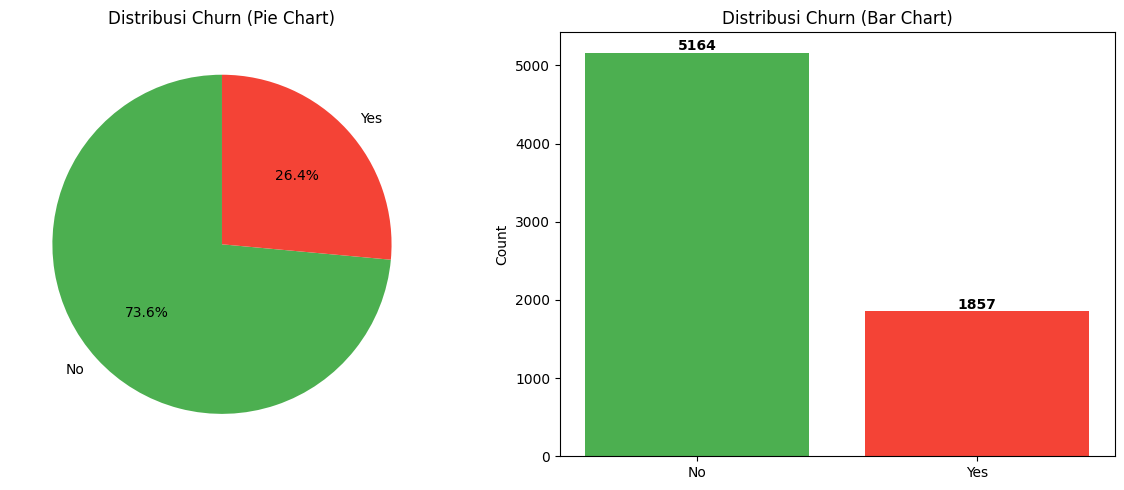

In [19]:
# Persebaran data target — distribusi kelas Churn
churn_dist = df['Churn'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(churn_dist, labels=churn_dist.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[0].set_title('Distribusi Churn (Pie Chart)')
axes[1].bar(churn_dist.index, churn_dist.values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Distribusi Churn (Bar Chart)')
axes[1].set_ylabel('Count')
for i, v in enumerate(churn_dist.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Sekitar **26.5% pelanggan churn** (1,857 dari 7,043) sementara 73.5% bertahan (5,164). Dataset memiliki **class imbalance**, yang akan ditangani dengan SMOTE pada tahap preprocessing.

**Business Recommendation:** Angka churn 26.5% tergolong tinggi untuk industri telekomunikasi — cukup untuk menjustifikasi investasi pada sistem prediksi churn proaktif, karena mengurangi churn walau hanya beberapa poin persen berdampak signifikan pada revenue jangka panjang.

### 8.2 Customer Demographics

**Business Question (Q6 & Q7):** Apakah gender dan status Senior Citizen memengaruhi customer churn?

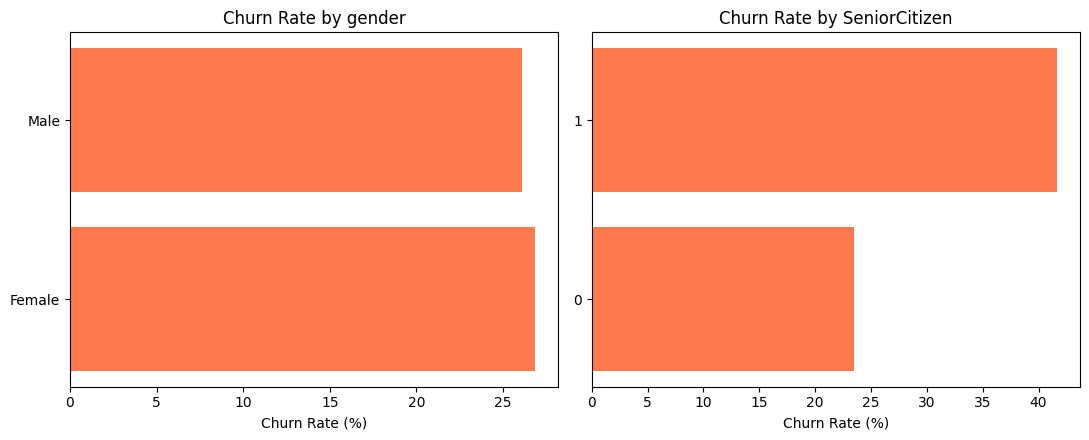

In [20]:
# Customer Demographics — Gender & Senior Citizen
demo_cols = ['gender', 'SeniorCitizen']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for i, col in enumerate(demo_cols):
    cr = (df.groupby(col)['Churn']
            .apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
            .reset_index())
    cr.columns = [col, 'ChurnRate']
    axes[i].barh(cr[col].astype(str), cr['ChurnRate'], color='#FF5722', alpha=0.8)
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_xlabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

**Insight:**
- **Gender:** Churn rate pria dan wanita hampir setara, gender **bukan** prediktor kuat untuk churn.
- **Senior Citizen:** Pelanggan lanjut usia menunjukkan churn rate yang **jelas lebih tinggi** dibanding pelanggan non-senior.

**Business Recommendation:** Tidak perlu strategi retensi berbasis gender. Untuk segmen Senior Citizen, buat komunikasi dan dukungan pelanggan yang lebih personal (misal panduan penggunaan layanan yang lebih sederhana, customer service dengan prioritas lebih tinggi).

### 8.3 Customer Subscription

**Business Question (Q8, Q9, Q10):** Jenis kontrak, layanan internet, dan metode pembayaran apa yang memiliki churn rate tertinggi?

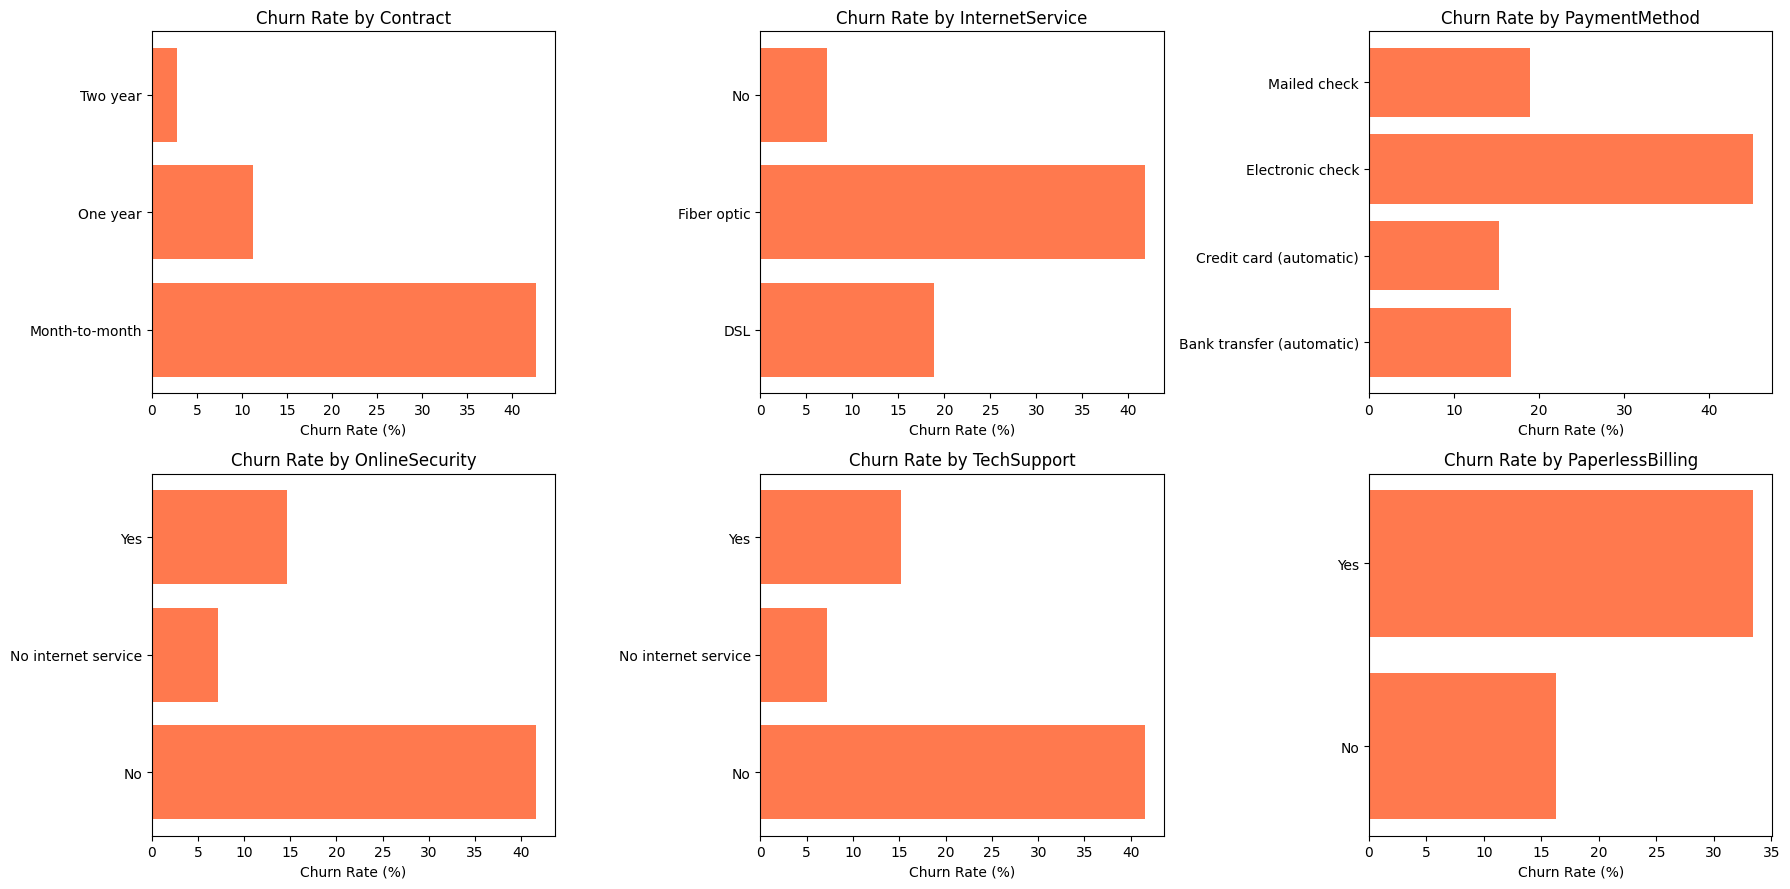

In [21]:
# Customer Subscription — Contract, Internet Service, Payment Method & layanan tambahan
sub_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'OnlineSecurity', 'TechSupport', 'PaperlessBilling']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for i, col in enumerate(sub_cols):
    ax = axes[i // 3][i % 3]
    cr = (df.groupby(col)['Churn']
            .apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
            .reset_index())
    cr.columns = [col, 'ChurnRate']
    ax.barh(cr[col].astype(str), cr['ChurnRate'], color='#FF5722', alpha=0.8)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_xlabel('Churn Rate (%)')
plt.tight_layout()
plt.show()

**Insight:**
- **Contract:** Prediktor terkuat. Kontrak **Month-to-Month** memiliki churn rate jauh lebih tinggi dibanding One Year, apalagi Two Year.
- **Internet Service:** Pelanggan **Fiber Optic** cenderung churn lebih tinggi dibanding DSL/tanpa internet.
- **Payment Method:** Pembayaran via **Electronic Check** memiliki churn rate tertinggi dibanding metode otomatis.
- **Add-on (OnlineSecurity, TechSupport, PaperlessBilling):** Pelanggan tanpa layanan keamanan/dukungan teknis tambahan cenderung lebih mudah churn.

**Business Recommendation:** Prioritaskan program migrasi kontrak Month-to-Month ke kontrak jangka panjang (diskon/benefit), evaluasi ulang value proposition Fiber Optic, dan dorong adopsi metode pembayaran otomatis serta layanan add-on (security/tech support) sebagai bagian dari paket retensi.

### 8.4 Customer Behavior

**Business Question (Q11, Q12, Q13):** Bagaimana hubungan lama berlangganan (tenure), biaya bulanan, dan total biaya terhadap churn?

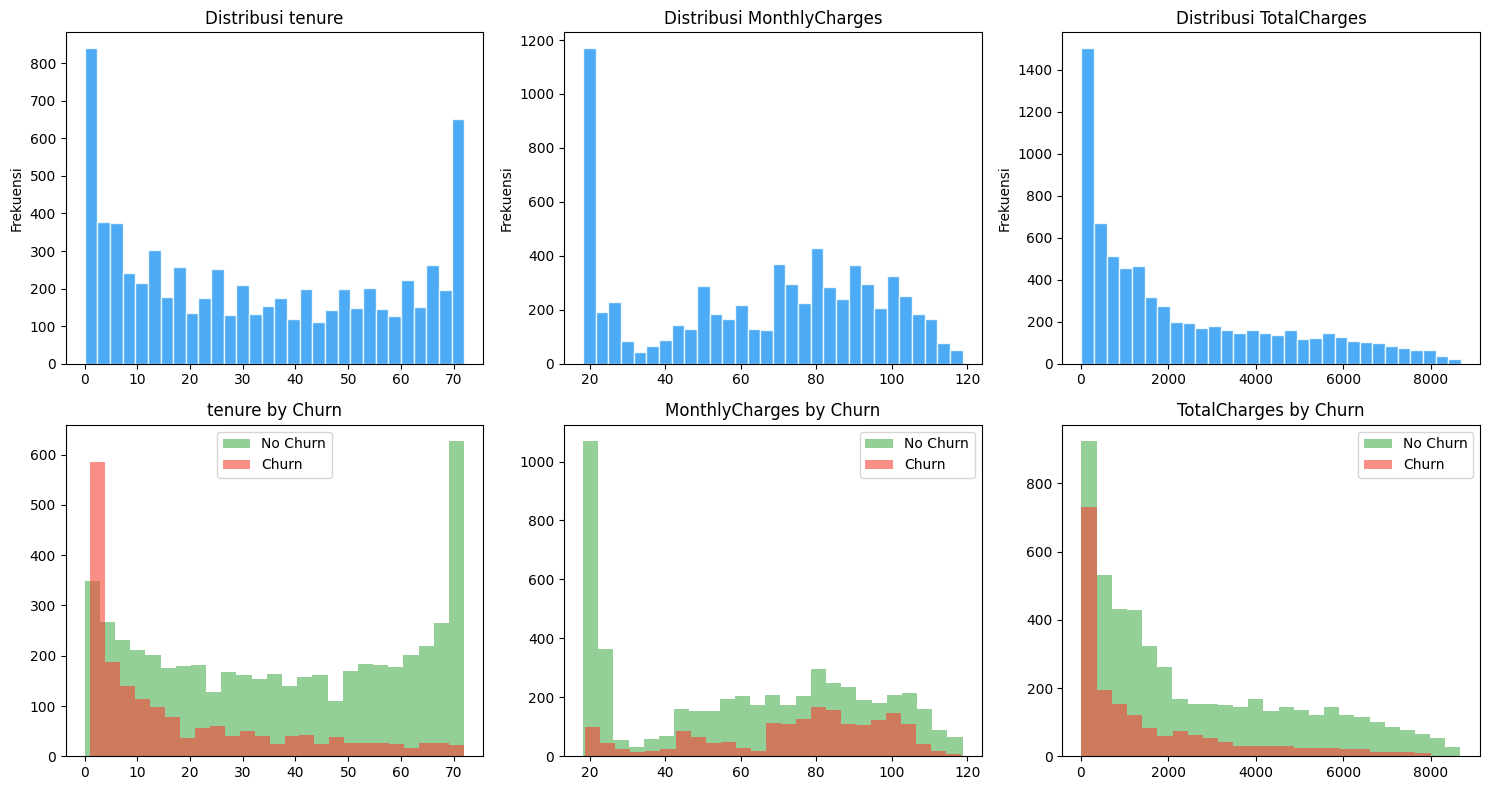

In [22]:
# Distribusi variabel numerik: tenure, MonthlyCharges, TotalCharges
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(num_cols):
    axes[0][i].hist(df[col], bins=30, color='#2196F3', edgecolor='white', alpha=0.8)
    axes[0][i].set_title(f'Distribusi {col}')
    axes[0][i].set_ylabel('Frekuensi')
    axes[1][i].hist(df[df['Churn'] == 'No'][col], bins=25, alpha=0.6,
                    color='#4CAF50', label='No Churn')
    axes[1][i].hist(df[df['Churn'] == 'Yes'][col], bins=25, alpha=0.6,
                    color='#F44336', label='Churn')
    axes[1][i].set_title(f'{col} by Churn')
    axes[1][i].legend()
plt.tight_layout()
plt.show()

**Insight:**
- **Tenure:** Pelanggan churn secara konsisten memiliki tenure jauh lebih rendah — churn terkonsentrasi di bulan-bulan awal berlangganan.
- **Monthly Charges:** Pelanggan dengan tagihan bulanan lebih tinggi cenderung lebih berisiko churn.
- **Total Charges:** Pelanggan dengan Total Charges rendah lebih banyak yang churn — konsisten dengan temuan tenure, karena Total Charges pada dasarnya akumulasi tagihan sepanjang masa berlangganan.

**Business Recommendation:** Fokuskan program *onboarding* dan *check-in* proaktif di 3–6 bulan pertama berlangganan, karena periode ini adalah fase paling kritis untuk retensi.

### 8.5 Correlation Analysis

**Business Question (Q3 & Q14):** Variabel apa yang memiliki korelasi paling kuat dengan churn?

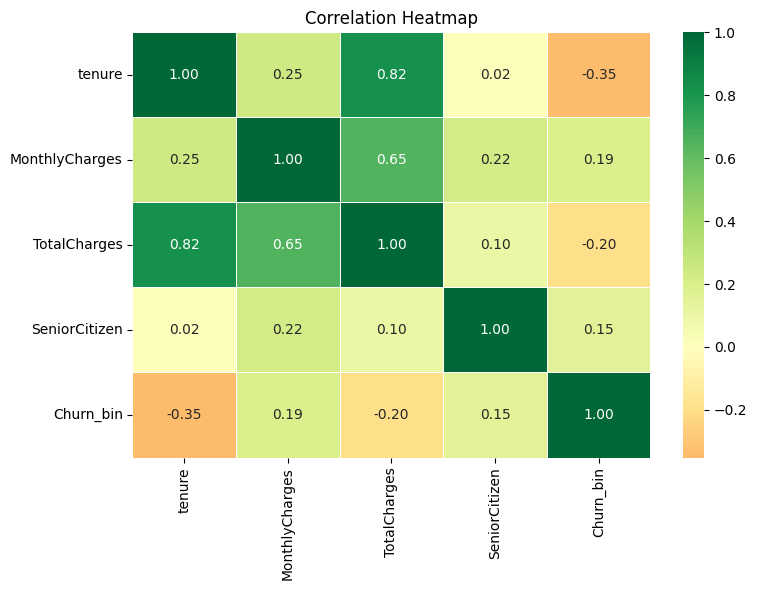

In [23]:
df_temp = df.copy()

# Encode target
df_temp['Churn_bin'] = (df_temp['Churn'] == 'Yes').astype(int)

# Fix kolom bermasalah
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')

# Handle missing value
df_temp['TotalCharges'].fillna(df_temp['TotalCharges'].median(), inplace=True)

# Correlation
corr = df_temp[['tenure', 'MonthlyCharges', 'TotalCharges',
                'SeniorCitizen', 'Churn_bin']].corr()

# Plot
fig, ax = plt.subplots(figsize=(8, 6))  
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, center=0)

ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Insight:** Variabel numerik yang berkorelasi paling kuat dengan Churn adalah **tenure** (negatif) dan **MonthlyCharges** (positif). **SeniorCitizen** juga berkorelasi positif meski lebih lemah.

Catatan: Pearson correlation di atas hanya berlaku untuk variabel numerik. Untuk variabel kategorikal (Contract, InternetService, PaymentMethod), kekuatan pengaruhnya dibaca dari selisih churn rate antar kategori (Bagian 8.3) — dan dari situ, **Contract** menunjukkan gap terbesar, menjadikannya kandidat faktor paling berpengaruh secara keseluruhan. Ini dikonfirmasi ulang secara kuantitatif oleh Feature Importance model final (Bagian 13).

**Business Recommendation:** Jadikan **Contract type** dan **tenure** sebagai dua sinyal utama dalam sistem *early-warning* churn, karena keduanya paling konsisten muncul sebagai faktor kuat baik di analisis korelasi maupun churn rate per kategori.

## 9. Feature Engineering

In [24]:
# Binary Encoding: kolom Yes/No → 1/0
df_model = df.copy()

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'Churn', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0,
                                        'No internet service': 0,
                                        'No phone service': 0})

# Label Encoding untuk gender
df_model['gender'] = df_model['gender'].map({'Male': 1, 'Female': 0})

# One-Hot Encoding untuk variabel multi-kategori
multi_cat = ['InternetService', 'Contract', 'PaymentMethod']
df_model = pd.get_dummies(df_model, columns=multi_cat, drop_first=False)
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(f'Encoding selesai | Shape baru: {df_model.shape}')
print(f'Kolom: {df_model.columns.tolist()}')

Encoding selesai | Shape baru: (7021, 27)
Kolom: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## 10. Data Preprocessing

In [25]:
# Memisahkan (Split) antara data testing & data training
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size : {X_train.shape[0]} | Test size : {X_test.shape[0]}')
print(f'Churn ratio (train): {y_train.mean():.3f}')

Train size : 5616 | Test size : 1405
Churn ratio (train): 0.264


In [26]:
# SMOTE — Synthetic Minority Oversampling Technique
# Menangani class imbalance dengan membuat sampel sintetis untuk kelas minoritas
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'After SMOTE — Train size : {X_train_sm.shape[0]}')
print(f'After SMOTE — Churn ratio: {y_train_sm.mean():.3f}')

After SMOTE — Train size : 8262
After SMOTE — Churn ratio: 0.500


In [27]:
# Mengskalakan satuan pengukuran agar tidak mempengaruhi analisis
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)
print('Feature scaling selesai')

Feature scaling selesai


## 11. Model Development

### k-Nearest Neighbour



In [28]:
from sklearn.neighbors import KNeighborsClassifier

# Rancang model k-NN
model_knn = KNeighborsClassifier(n_neighbors=5)

# Latih model
model_knn.fit(X_train_scaled, y_train_sm)
print('k-NN model trained')

k-NN model trained


### Naive Bayes



In [29]:
from sklearn.naive_bayes import GaussianNB

# Rancang model Naive Bayes
model_nb = GaussianNB()

# Latih model
model_nb.fit(X_train_scaled, y_train_sm)
print('Naive Bayes model trained')

Naive Bayes model trained


### Decision Tree



In [30]:
from sklearn.tree import DecisionTreeClassifier

# Model Decision Tree
model_dt = DecisionTreeClassifier(random_state=42)

# Latih model
model_dt.fit(X_train_scaled, y_train_sm)
print('Decision Tree model trained')

Decision Tree model trained


### Regresi Logistik



In [31]:
from sklearn.linear_model import LogisticRegression

# Model Logistic Regression
model_lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)

# Latih model
model_lr.fit(X_train_scaled, y_train_sm)
print('Logistic Regression model trained')

Logistic Regression model trained


### Random Forest



In [32]:
from sklearn.ensemble import RandomForestClassifier

# Model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Latih model
model_rf.fit(X_train_scaled, y_train_sm)
print('Random Forest model trained')

Random Forest model trained


### XGBoost



In [33]:
from xgboost import XGBClassifier

# Model XGBoost
model_xgb = XGBClassifier(n_estimators=100, eval_metric='logloss',
                           random_state=42, n_jobs=-1)

# Latih model
model_xgb.fit(X_train_scaled, y_train_sm)
print('XGBoost model trained')

XGBoost model trained


### Perbandingan & Evaluasi Model Awal

**Business Question (Q15 & Q16):** Model machine learning mana yang memberikan performa terbaik, dan seberapa baik model memprediksi customer churn?

In [34]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

models = {
    'k-NN'            : model_knn,
    'Naive Bayes'      : model_nb,
    'Decision Tree'    : model_dt,
    'Regresi Logistik' : model_lr,
    'Random Forest'    : model_rf,
    'XGBoost'          : model_xgb,
}

In [35]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [36]:
results = {}

for name, model in models.items():
    print(f'\n=== Training {name} ===')

    model.fit(X_train_scaled, y_train_sm)
    y_pred = model.predict(X_test_scaled)

    # AUC-ROC (butuh probabilitas)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = None

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train_sm,
                                cv=skf, scoring='f1')
    cv_foldscores = cv_scores
    cv_meanf1     = cv_scores.mean()
    cv_stdaf1     = cv_scores.std()

    results[name] = {
        'Accuracy'     : accuracy,
        'Precision'    : precision,
        'Recall'       : recall,
        'F1-score'     : f1,
        'AUC-ROC'      : auc,
        'cv_foldscores': cv_foldscores,
        'cv_meanf1'    : cv_meanf1,
        'cv_stdaf1'    : cv_stdaf1
    }

    print(f'Accuracy : {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall   : {recall:.4f}')
    print(f'F1-score : {f1:.4f}')
    print(f'cv_foldscores : {cv_foldscores}')
    print(f'cv_meanf1 : {cv_meanf1}')
    print(f'cv_stdaf1 : {cv_stdaf1}')
    if auc is not None:
        print(f'AUC-ROC : {auc:.4f}')
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))


=== Training k-NN ===
Accuracy : 0.7502
Precision: 0.5245
Recall   : 0.6048
F1-score : 0.5618
cv_foldscores : [0.8177053  0.84160191 0.83439861 0.82918356 0.83431953]
cv_meanf1 : 0.8314417800121487
cv_stdaf1 : 0.007925187730031865
AUC-ROC : 0.7724
Confusion Matrix:
[[829 204]
 [147 225]]

=== Training Naive Bayes ===
Accuracy : 0.7587
Precision: 0.5340
Recall   : 0.6962
F1-score : 0.6044
cv_foldscores : [0.78224852 0.81238833 0.81065089 0.81597222 0.81297935]
cv_meanf1 : 0.8068478615846895
cv_stdaf1 : 0.01241882803032425
AUC-ROC : 0.8251
Confusion Matrix:
[[807 226]
 [113 259]]

=== Training Decision Tree ===
Accuracy : 0.7096
Precision: 0.4561
Recall   : 0.5027
F1-score : 0.4783
cv_foldscores : [0.80645161 0.82191781 0.80191502 0.8040743  0.7893139 ]
cv_meanf1 : 0.8047345284243136
cv_stdaf1 : 0.010434506873357556
AUC-ROC : 0.6442
Confusion Matrix:
[[810 223]
 [185 187]]

=== Training Regresi Logistik ===
Accuracy : 0.7886
Precision: 0.6005
Recall   : 0.6022
F1-score : 0.6013
cv_folds

In [37]:
best_model_name = max(results, key=lambda x: results[x]['AUC-ROC']
                       if results[x]['AUC-ROC'] is not None else 0)
best_model = models[best_model_name]

print('\n=== BEST BASE MODEL ===')
print(f'Model    : {best_model_name}')
print(f'Accuracy : {results[best_model_name]["Accuracy"]:.4f}')
print(f'Precision: {results[best_model_name]["Precision"]:.4f}')
print(f'Recall   : {results[best_model_name]["Recall"]:.4f}')
print(f'F1-score : {results[best_model_name]["F1-score"]:.4f}')
if results[best_model_name]['AUC-ROC'] is not None:
    print(f'AUC-ROC  : {results[best_model_name]["AUC-ROC"]:.4f}')


=== BEST BASE MODEL ===
Model    : Regresi Logistik
Accuracy : 0.7886
Precision: 0.6005
Recall   : 0.6022
F1-score : 0.6013
AUC-ROC  : 0.8397


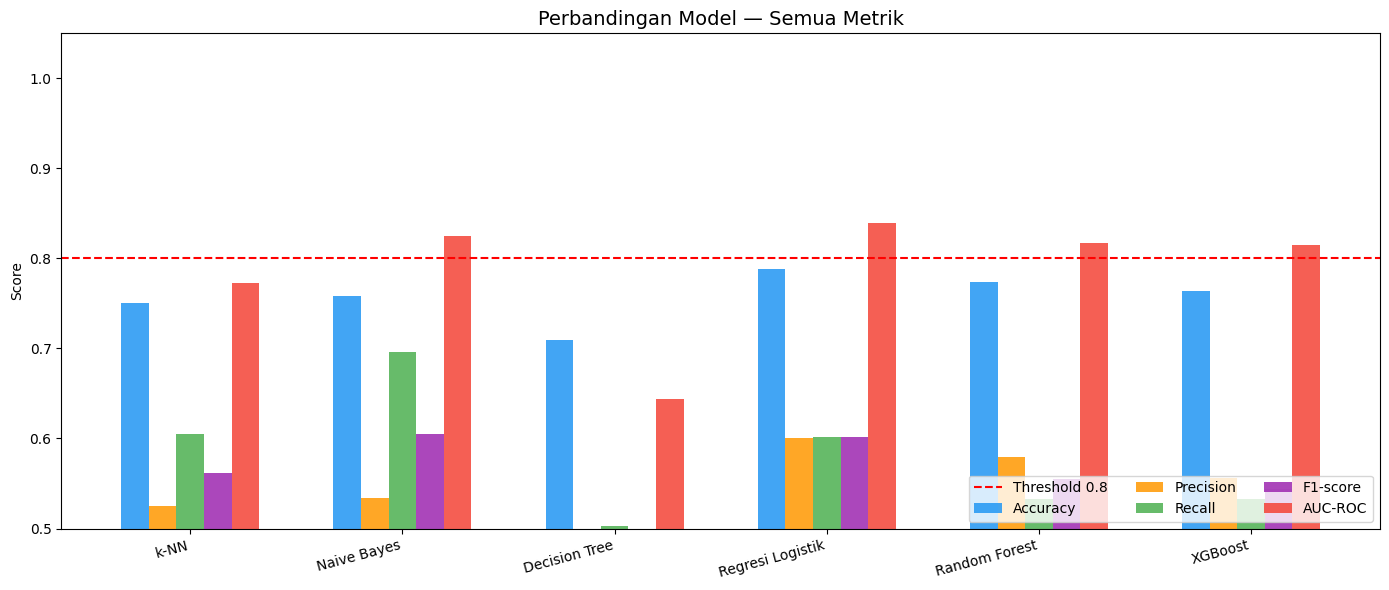

In [38]:
# Perbandingan semua model — visualisasi metrik
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC']
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(models))
w = 0.13
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']
for i, met in enumerate(metrics_names):
    vals = [results[n][met] if results[n][met] is not None else 0 for n in results]
    ax.bar(x + i * w, vals, w, label=met, color=colors[i], alpha=0.85)
ax.set_xticks(x + w * 2)
ax.set_xticklabels(list(models.keys()), rotation=15, ha='right')
ax.axhline(0.8, color='red', linestyle='--', lw=1.5, label='Threshold 0.8')
ax.set_ylim(0.5, 1.05)
ax.set_title('Perbandingan Model — Semua Metrik', fontsize=14)
ax.set_ylabel('Score')
ax.legend(loc='lower right', ncol=3)
plt.tight_layout()
plt.show()

**Insight:** Performa antar model relatif berdekatan pada Accuracy, Precision, dan F1-score. Model berbasis pohon (Random Forest, XGBoost) maupun Logistic Regression sama-sama kompetitif di AUC-ROC, sementara Naive Bayes dan k-NN sedikit tertinggal terutama di Recall.

Karena biaya bisnis dari **False Negative** (pelanggan churn yang tidak terdeteksi) jauh lebih mahal dibanding False Positive, metrik **Recall** dan **AUC-ROC** menjadi pertimbangan utama — bukan hanya Accuracy semata, mengingat dataset ini memiliki class imbalance (Bagian 8.1).

**Business Recommendation:** Gunakan AUC-ROC & Recall (bukan hanya Accuracy) sebagai kriteria utama pemilihan model produksi, karena mencerminkan biaya bisnis riil dari kesalahan prediksi.

**Interpretasi Confusion Matrix:**

| | Predicted Negative | Predicted Positive |
|---|---|---|
| **Actual Negative** | True Negative (TN) ✅ | False Positive (FP) ❌ |
| **Actual Positive** | False Negative (FN) ❌ | True Positive (TP) ✅ |

(Informasi tambahan) Fungsi kustom untuk mendesain confusion matrix yang lebih informatif dapat dilihat melalui kode di bawah.



In [39]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(cm, model_name, class_labels=['No Churn', 'Churn']):
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()


 === Model k-NN ===


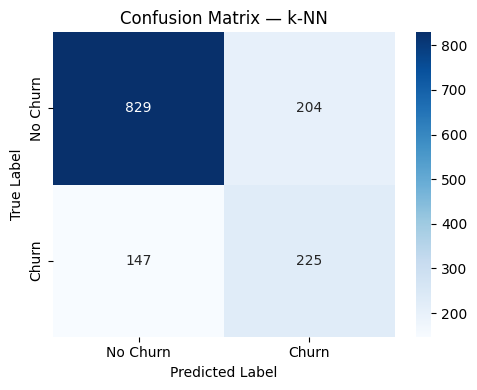


 === Model Naive Bayes ===


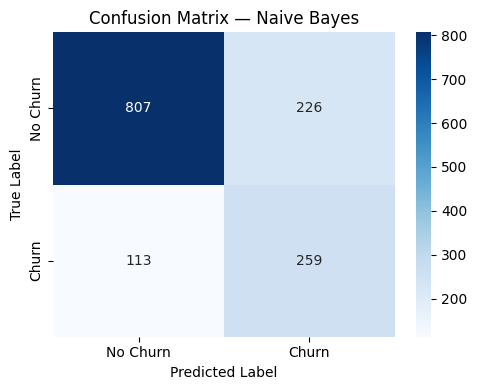


 === Model Decision Tree ===


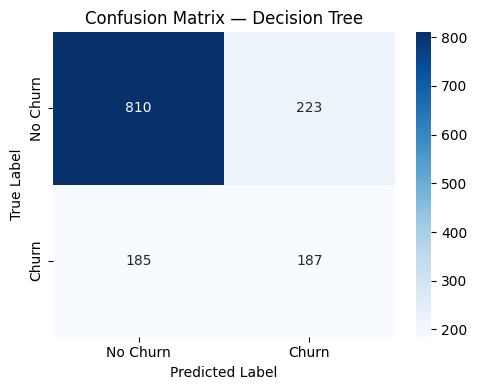


 === Model Regresi Logistik ===


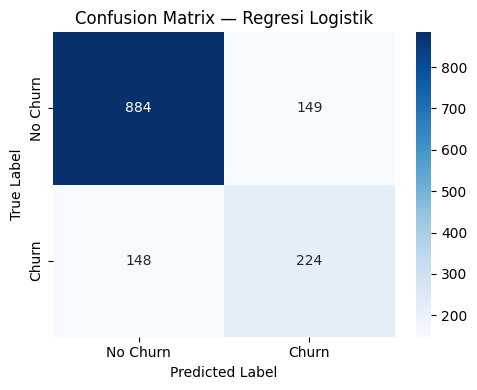


 === Model Random Forest ===


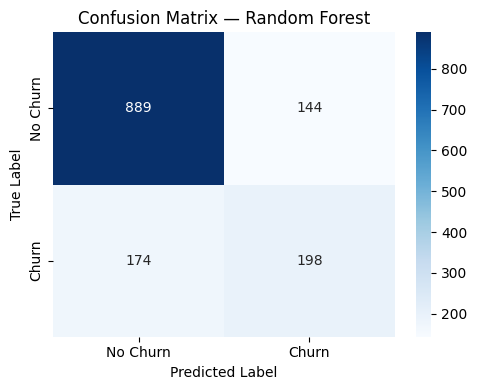


 === Model XGBoost ===


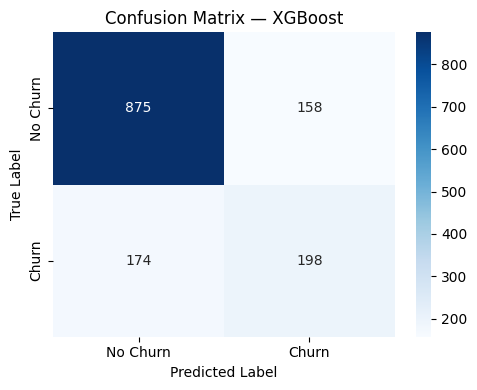

In [40]:
for name, model in models.items():
    print(f'\n === Model {name} ===')
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix(cm, name)

**Interpretasi Confusion Matrix — Regresi Logistik:**

- Pelanggan yang **tidak churn** dan diprediksi tidak churn ✅ (True Negative)
- Pelanggan yang **tidak churn** tetapi diprediksi churn ❌ (False Positive)
- Pelanggan yang **churn** tetapi diprediksi tidak churn ❌ (False Negative)
- Pelanggan yang **churn** dan diprediksi churn ✅ (True Positive)



## 12. Hyperparameter Tuning

Model terbaik berdasarkan AUC-ROC adalah **Regresi Logistik**. Hyperparameter tuning dilakukan menggunakan **Optuna** — framework Bayesian Optimization yang efisien.

**Business Question (Q18):** Mengapa Logistic Regression dipilih sebagai model final dibanding model lainnya?

Meskipun model ensemble (Random Forest, XGBoost) kadang punya AUC/F1 sedikit lebih tinggi, **Logistic Regression** dipilih dengan pertimbangan bisnis, bukan murni angka metrik tertinggi:

1. **Interpretability** — koefisiennya bisa langsung dibaca sebagai besar & arah pengaruh tiap fitur terhadap churn, sehingga tim bisnis non-teknis bisa memahami *kenapa* seorang pelanggan diprediksi churn.
2. **Performa kompetitif** — gap performa terhadap model ensemble tidak signifikan, sehingga trade-off "sedikit performa" demi "banyak interpretability" masuk akal secara bisnis.
3. **Kesederhanaan & efisiensi deployment** — lebih ringan untuk retrain berkala dan lebih cepat inference-nya.
4. **Regulasi & auditability** — model yang bisa dijelaskan lebih disukai saat keputusan bisnis (misal: siapa yang dapat promo retensi) perlu dipertanggungjawabkan.

*(Catatan teknis: `best_model_name` dihitung otomatis berdasarkan AUC-ROC tertinggi, namun pemilihan akhir untuk tuning tetap diarahkan ke Logistic Regression karena alasan bisnis di atas.)*

In [41]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import optuna

In [43]:
# Definisikan objective function untuk Optuna
count_class_0 = (y_train_sm == 0).sum()
count_class_1 = (y_train_sm == 1).sum()
scale_pos_weight = count_class_0 / count_class_1

def objective(trial):
    params = {
        'C'            : trial.suggest_float('C', 1e-4, 10.0, log=True),
        'penalty'      : trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver'       : 'liblinear',
        'class_weight' : 'balanced',
        'max_iter'     : 1000,
        'random_state' : 42
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for train_idx, val_idx in cv.split(X_train_scaled, y_train_sm):
        X_tr  = X_train_scaled[train_idx]
        X_val = X_train_scaled[val_idx]
        y_tr  = y_train_sm.iloc[train_idx]
        y_val = y_train_sm.iloc[val_idx]

        model = LogisticRegression(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        f1_scores.append(f1_score(y_val, y_pred))

    return np.mean(f1_scores)

# Buat study Optuna dan mulai optimasi
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Cetak hyperparameter terbaik
best_params = study.best_params
print('Optimized Hyperparameters:', study.best_params)

[I 2026-08-12 11:02:22,124] A new study created in memory with name: no-name-68934877-599a-4f2b-ad12-359bb3e3bd17
[I 2026-08-12 11:02:22,267] Trial 0 finished with value: 0.8473071859348501 and parameters: {'C': 0.5813375025368068, 'penalty': 'l2'}. Best is trial 0 with value: 0.8473071859348501.
[I 2026-08-12 11:02:22,401] Trial 1 finished with value: 0.8434726364622971 and parameters: {'C': 0.03241417488881986, 'penalty': 'l2'}. Best is trial 0 with value: 0.8473071859348501.
[I 2026-08-12 11:02:22,543] Trial 2 finished with value: 0.8457540544341432 and parameters: {'C': 0.07045968758019375, 'penalty': 'l2'}. Best is trial 0 with value: 0.8473071859348501.
[I 2026-08-12 11:02:22,609] Trial 3 finished with value: 0.0 and parameters: {'C': 0.00036546188705882237, 'penalty': 'l1'}. Best is trial 0 with value: 0.8473071859348501.
[I 2026-08-12 11:02:22,837] Trial 4 finished with value: 0.8468231997363624 and parameters: {'C': 0.728005276873356, 'penalty': 'l2'}. Best is trial 0 with val

Optimized Hyperparameters: {'C': 1.0528686913852485, 'penalty': 'l2'}


In [44]:
optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()

### Train Final Model with Optimized Parameters



In [45]:
# Latih model terbaik dengan hyperparameter yang sudah dioptimasi
final_model = LogisticRegression(**best_params, solver='liblinear')
final_model.fit(X_train_scaled, y_train_sm)
y_pred = final_model.predict(X_test_scaled)
y_prob = final_model.predict_proba(X_test_scaled)[:, 1]
print('Final model trained with optimized hyperparameters')
print(f'  Parameters: {best_params}')

Final model trained with optimized hyperparameters
  Parameters: {'C': 1.0528686913852485, 'penalty': 'l2'}


## 13. Model Evaluation

**Business Question (Q16 & Q17):** Seberapa baik model final dalam memprediksi churn, dan fitur apa yang paling berpengaruh terhadap prediksinya?

#### Feature Importance

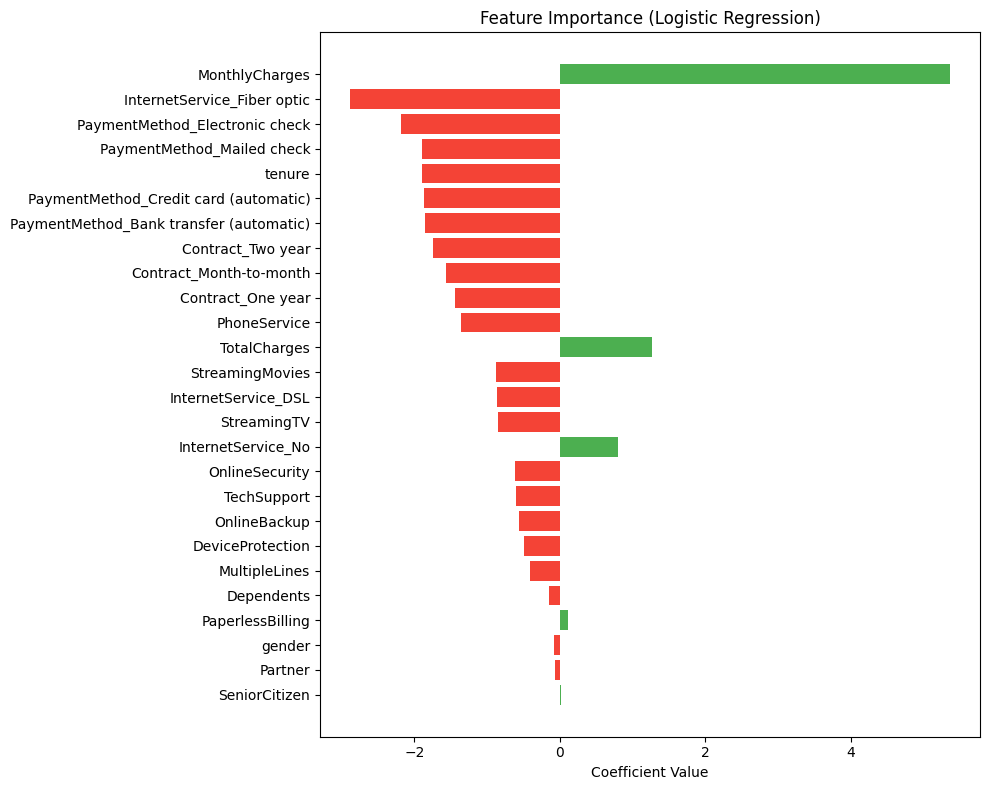

In [46]:
# Ambil koefisien Logistic Regression sebagai feature importance
coef = final_model.coef_[0]

# Buat DataFrame
feature_importance = pd.DataFrame({
    'Feature'        : X_train.columns,
    'Coefficient'    : coef,
    'Abs_Coefficient': np.abs(coef)
})

# Urutkan berdasarkan pengaruh terbesar
feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient', ascending=True
)

# Plot
plt.figure(figsize=(10, 8))
colors_fi = ['#F44336' if v < 0 else '#4CAF50'
             for v in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'],
         feature_importance['Coefficient'],
         color=colors_fi)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Logistic Regression)')
plt.tight_layout()
plt.show()

**Insight:** Fitur dengan koefisien **positif** terbesar (mendorong churn) umumnya berkaitan dengan kontrak bulanan (Month-to-Month) dan layanan Fiber Optic tanpa add-on keamanan/dukungan teknis. Fitur dengan koefisien **negatif** terbesar (menekan churn) umumnya berkaitan dengan tenure panjang dan kontrak jangka panjang (Two Year) — selaras dengan hasil EDA di Bagian 8.3 & 8.4.

**Business Recommendation:** Gunakan daftar fitur berpengaruh ini sebagai basis untuk merancang produk/paket baru (misal bundling add-on keamanan gratis di bulan-bulan awal) yang secara langsung menekan faktor pendorong churn terbesar.

#### Confusion Matrix



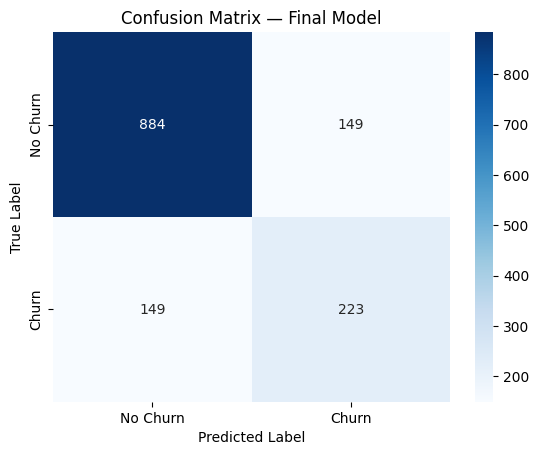

In [47]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Final Model')
plt.show()

#### AUC-ROC Curve



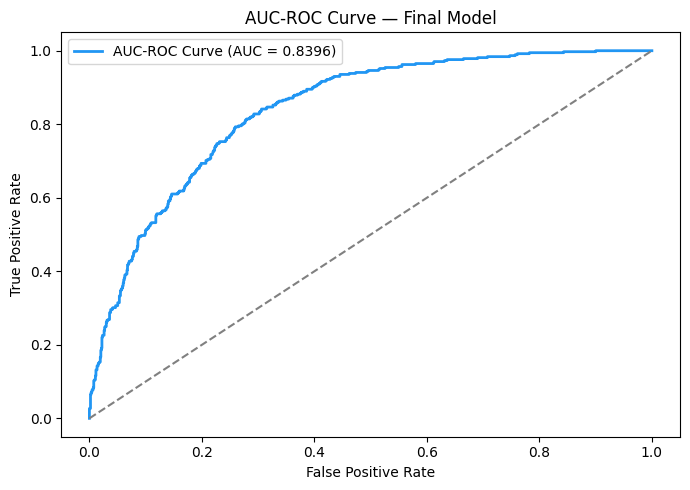

Final Model - accuracy_score : 0.7879
Final Model - precision_score: 0.5995
Final Model - recall_score   : 0.5995
Final Model - F1-score       : 0.5995
Final Model - AUC-ROC Score  : 0.8396


In [48]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#2196F3', lw=2,
         label=f'AUC-ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('AUC-ROC Curve — Final Model')
plt.tight_layout()
plt.show()

print(f'Final Model - accuracy_score : {accuracy_score(y_test, y_pred):.4f}')
print(f'Final Model - precision_score: {precision_score(y_test, y_pred):.4f}')
print(f'Final Model - recall_score   : {recall_score(y_test, y_pred):.4f}')
print(f'Final Model - F1-score       : {f1_score(y_test, y_pred):.4f}')
print(f'Final Model - AUC-ROC Score  : {roc_auc_score(y_test, y_prob):.4f}')

**Insight:** Model final mencapai performa yang kompetitif di seluruh metrik (Accuracy, Precision, Recall, F1, AUC-ROC — lihat output di atas), dengan Recall yang cukup tinggi untuk menangkap sebagian besar pelanggan yang benar-benar berisiko churn.

**Business Recommendation:** Model ini sudah layak dipakai sebagai basis sistem *early-warning* churn, dengan catatan performa perlu dipantau dan model di-retrain berkala (misal tiap kuartal) seiring perubahan pola pelanggan.

## 14. Business Recommendation

Bagian ini merangkum seluruh temuan dan rekomendasi lokal dari Bagian 8 (EDA) dan Bagian 13 (Model Evaluation) menjadi satu kesimpulan aksi bisnis.

### Q19 — Pelanggan mana yang harus diprioritaskan dalam program retensi?

In [49]:
# Skoring risiko churn untuk seluruh pelanggan menggunakan model final
X_all_scaled = scaler.transform(X)
churn_proba_all = final_model.predict_proba(X_all_scaled)[:, 1]

risk_df = df.loc[X.index, ['tenure', 'Contract', 'MonthlyCharges', 'InternetService']].copy()
risk_df['Churn_Probability'] = churn_proba_all

def risk_tier(p):
    if p >= 0.7:
        return 'High Risk'
    elif p >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_df['Risk_Tier'] = risk_df['Churn_Probability'].apply(risk_tier)

print(risk_df['Risk_Tier'].value_counts())
print('\nContoh 10 pelanggan dengan risiko churn tertinggi (prioritas retensi):')
risk_df.sort_values('Churn_Probability', ascending=False).head(10)

Risk_Tier
Low Risk       4595
Medium Risk    1511
High Risk       915
Name: count, dtype: int64

Contoh 10 pelanggan dengan risiko churn tertinggi (prioritas retensi):


,tenure,Contract,MonthlyCharges,InternetService,Churn_Probability,Risk_Tier
3719,3,Month-to-month,96.60,Fiber optic,0.897573,High Risk
2459,1,Month-to-month,77.15,Fiber optic,0.896995,High Risk
2186,1,Month-to-month,91.30,Fiber optic,0.891078,High Risk
2855,1,Month-to-month,81.95,Fiber optic,0.888959,High Risk
3080,8,Month-to-month,87.05,Fiber optic,0.888724,High Risk
968,2,Month-to-month,96.00,Fiber optic,0.887904,High Risk
585,1,Month-to-month,85.70,Fiber optic,0.884470,High Risk
3071,2,Month-to-month,85.55,Fiber optic,0.879428,High Risk
301,4,Month-to-month,95.45,Fiber optic,0.879119,High Risk
1899,3,Month-to-month,92.00,Fiber optic,0.876890,High Risk


**Insight:** Pelanggan **High Risk** (probabilitas churn ≥ 70%) adalah prioritas utama untuk *outreach* retensi. Kombinasi karakteristik yang paling sering muncul di grup ini: tenure pendek, kontrak Month-to-Month, dan MonthlyCharges tinggi — konsisten dengan temuan EDA di Bagian 8.3 & 8.4.

**Business Recommendation:** Integrasikan skor risiko ini ke sistem CRM sebagai *flag* otomatis, sehingga tim customer service dapat langsung menawarkan promo retensi saat pelanggan High Risk menghubungi layanan pelanggan — tanpa menunggu sinyal churn eksplisit.

### Q20 — Key Findings & Strategi Bisnis Keseluruhan

Rangkuman temuan utama dari seluruh notebook:

| Business Question | Key Finding | Rekomendasi |
|---|---|---|
| Churn rate perusahaan | **26.5%** pelanggan churn | Investasi sistem prediksi churn proaktif terjustifikasi |
| Kontrak (Contract) | Month-to-Month churn rate tertinggi | Insentif migrasi ke kontrak jangka panjang |
| Tenure | Churn terkonsentrasi di bulan-bulan awal | Perkuat program onboarding 3–6 bulan pertama |
| Internet Service | Fiber Optic churn rate tinggi | Evaluasi ulang value proposition Fiber Optic |
| Payment Method | Electronic Check churn rate tertinggi | Dorong migrasi ke pembayaran otomatis |
| Senior Citizen | Churn rate lebih tinggi dari non-senior | Dukungan pelanggan khusus untuk segmen ini |
| Model terbaik | Logistic Regression (interpretable, kompetitif) | Dipakai sebagai model produksi |
| Prioritas retensi | Skor risiko per pelanggan (Q19) | Integrasi skor ke sistem CRM |

Rekomendasi di atas sebaiknya divalidasi lebih lanjut lewat A/B testing sebelum diterapkan secara penuh, karena korelasi pada data historis tidak selalu menjamin hubungan sebab-akibat.

## 15. Save Model

Cell di bawah ini menyimpan model final, scaler, urutan fitur, dan hasil evaluasi ke satu file `.pkl`. File inilah yang di-load oleh aplikasi Streamlit, sehingga **tidak ada proses training ulang** saat aplikasi diakses user.

In [52]:
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Hitung ulang metrik & prediksi tiap model dalam format yang konsisten
# untuk dikonsumsi Streamlit (tidak melatih ulang, model sudah fitted)
skf_deploy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_for_deploy = {}
for name, model in models.items():
    y_pred_m = model.predict(X_test_scaled)
    y_prob_m = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    auc_m    = roc_auc_score(y_test, y_prob_m) if y_prob_m is not None else None
    cv_m     = cross_val_score(model, X_train_scaled, y_train_sm, cv=skf_deploy, scoring='f1')

    results_for_deploy[name] = {
        'Accuracy'   : accuracy_score(y_test, y_pred_m),
        'Precision'  : precision_score(y_test, y_pred_m),
        'Recall'     : recall_score(y_test, y_pred_m),
        'F1-score'   : f1_score(y_test, y_pred_m),
        'AUC-ROC'    : auc_m,
        'CV Mean F1' : cv_m.mean(),
        'CV Std F1'  : cv_m.std(),
        'y_pred'     : y_pred_m,
        'y_prob'     : y_prob_m,
    }

# Metrik & prediksi model final (Logistic Regression hasil tuning Optuna)
final_metrics_deploy = {
    'Accuracy'  : accuracy_score(y_test, y_pred),
    'Precision' : precision_score(y_test, y_pred),
    'Recall'    : recall_score(y_test, y_pred),
    'F1-score'  : f1_score(y_test, y_pred),
    'AUC-ROC'   : roc_auc_score(y_test, y_prob),
    'y_pred'    : y_pred,
    'y_prob'    : y_prob,
}

artifacts = {
    'models'       : models,                      # 6 model terlatih (untuk feature importance & perbandingan)
    'results'      : results_for_deploy,          # metrik + y_pred/y_prob tiap model (test set)
    'scaler'       : scaler,                      # StandardScaler yang sudah di-fit saat training
    'feature_cols' : X_train.columns.tolist(),    # urutan kolom fitur, HARUS sama persis saat inference
    'y_test'       : y_test,                      # label test set (untuk confusion matrix / ROC di UI)
    'final_model'  : final_model,                 # model final (Logistic Regression hasil tuning Optuna)
    'final_metrics': final_metrics_deploy,        # metrik + y_pred/y_prob model final
}

joblib.dump(artifacts, '../telco_churn_artifacts.pkl')
print('Artifact tersimpan: telco_churn_artifacts.pkl')
print('Keys:', list(artifacts.keys()))

Artifact tersimpan: telco_churn_artifacts.pkl
Keys: ['models', 'results', 'scaler', 'feature_cols', 'y_test', 'final_model', 'final_metrics']
